In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import holidays

# Model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings 
warnings.filterwarnings("ignore")

import shap

In [98]:
data = pd.read_csv('data_processing.csv',index_col=0)
data.head(4)

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0
2,2021-01-01,67LPLP,2576.0,100943.14,72128.00,1,1,4,53,0
3,2021-01-01,6HSD4J,1078.0,52806.91,33806.08,1,1,4,53,0


#### add temporal learning features: 

In [99]:
data['lag1'] = data.groupby('sku')['qty'].shift(1)
data['lag7'] = data.groupby('sku')['qty'].shift(7)
data['lag30'] = data.groupby('sku')['qty'].shift(30)
data['rolling_mean_7'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=7,min_periods=1).mean())
data['rolling_mean_30'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=30,min_periods=1).mean())   
data['rolling_std_7'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=7,min_periods=1).std())
data['rolling_std_30'] = data.groupby('sku')['qty'].transform(lambda x: x.rolling(window=30,min_periods=1).std())

data.head()

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0,NaN,NaN,NaN,5822.0,5822.0,NaN,NaN
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0,NaN,NaN,NaN,984.0,984.0,NaN,NaN
2,2021-01-01,67LPLP,2576.0,100943.14,72128.00,1,1,4,53,0,NaN,NaN,NaN,2576.0,2576.0,NaN,NaN
3,2021-01-01,6HSD4J,1078.0,52806.91,33806.08,1,1,4,53,0,NaN,NaN,NaN,1078.0,1078.0,NaN,NaN
4,2021-01-01,7XL27C,306.0,55490.65,17564.40,1,1,4,53,0,NaN,NaN,NaN,306.0,306.0,NaN,NaN


In [100]:
data.isnull().sum()

shipped_date         0
sku                  0
qty                  0
revenue              0
COGS                 0
month                0
day                  0
dayofweek            0
weekofyear           0
is_even_day          0
lag1                10
lag7                70
lag30              300
rolling_mean_7       0
rolling_mean_30      0
rolling_std_7       10
rolling_std_30      10
dtype: int64

#### add features of SKU:

In [101]:
data_test = data.copy()

data_test["shipped_date"] = pd.to_datetime(data_test["shipped_date"])
data_test = data_test.sort_values(["sku", "shipped_date"])

data_test["dow"] = data_test["shipped_date"].dt.weekday  # 0 = Monday

data_test["mean_qty_sku_dow"] = (
    data_test.groupby(["sku", "dow"])["qty"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

data_test["month"] = data_test["shipped_date"].dt.month

data_test["mean_qty_sku_month"] = (
    data_test.groupby(["sku", "month"])["qty"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [102]:
data_test

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,dow,mean_qty_sku_dow,mean_qty_sku_month
7,2021-01-01,1JKADT,3038.0,46742.67,33627.72,1,1,4,53,0,NaN,NaN,NaN,3038.000000,3038.000000,NaN,NaN,4,NaN,NaN
17,2021-01-02,1JKADT,0.0,0.00,0.00,1,2,5,53,1,3038.0,NaN,NaN,1519.000000,1519.000000,2148.190401,2148.190401,5,NaN,3038.000000
27,2021-01-03,1JKADT,3430.0,52363.76,36846.43,1,3,6,53,0,0.0,NaN,NaN,2156.000000,2156.000000,1877.409918,1877.409918,6,NaN,1519.000000
37,2021-01-04,1JKADT,0.0,0.00,0.00,1,4,0,1,1,3430.0,NaN,NaN,1617.000000,1617.000000,1873.996443,1873.996443,0,NaN,2156.000000
47,2021-01-05,1JKADT,1666.0,25633.08,17934.78,1,5,1,1,0,0.0,NaN,NaN,1626.800000,1626.800000,1623.076462,1623.076462,1,NaN,1617.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629,2021-12-29,Y6HWKQ,1804.0,58038.29,37884.00,12,29,2,52,0,0.0,0.0,1476.0,1347.142857,871.933333,1311.023446,1016.791639,2,516.117647,869.785714
3639,2021-12-30,Y6HWKQ,0.0,0.00,0.00,12,30,3,52,1,1804.0,2050.0,0.0,1054.285714,871.933333,1356.043475,1016.791639,3,537.019608,902.000000
3649,2021-12-31,Y6HWKQ,2706.0,87057.43,56826.00,12,31,4,52,0,0.0,0.0,1886.0,1440.857143,899.266667,1390.665480,1055.284695,4,630.769231,871.933333
3659,2022-01-01,Y6HWKQ,0.0,0.00,0.00,1,1,5,52,0,2706.0,2870.0,0.0,1030.857143,899.266667,1320.392799,1055.284695,5,558.230769,552.838710


In [103]:
data_model = data_test.copy()
data_model["qty_log"] = np.log1p(data_model["qty"])  # log(1 + qty) 

data_model = data_model.sort_values("shipped_date")

split_idx = int(len(data_model) * 0.8)

train = data_model.iloc[:split_idx]
test  = data_model.iloc[split_idx:]
print(train.shape)
print(test.shape)

(2936, 21)
(734, 21)


In [104]:
train.head(4)

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,...,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,dow,mean_qty_sku_dow,mean_qty_sku_month,qty_log
7,2021-01-01,1JKADT,3038.0,46742.67,33627.72,1,1,4,53,0,...,NaN,NaN,3038.0,3038.0,NaN,NaN,4,NaN,NaN,8.019284
8,2021-01-01,HK1R6J,144.0,46365.99,19404.00,1,1,4,53,0,...,NaN,NaN,144.0,144.0,NaN,NaN,4,NaN,NaN,4.976734
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0,...,NaN,NaN,5822.0,5822.0,NaN,NaN,4,NaN,NaN,8.669571
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0,...,NaN,NaN,984.0,984.0,NaN,NaN,4,NaN,NaN,6.892642


In [105]:
train_model = train.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])
test_model = test.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])

#### log (qty) and scaling: 

In [106]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = train_model.drop(columns=["qty_log"])
y_train = train_model["qty_log"]

X_test = test_model.drop(columns=["qty_log"])
y_test = test_model["qty_log"]

X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### apply the model: 

##### RF: (baseline)

In [107]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y_train)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/naaani/Documents/unigap/forecasting/forecast_env/lib/python3.13/site-packages/sklearn/utils/_repr_html/estimator.js'

FileNotFoundError: [Errno 2] No such file or directory: '/Users/naaani/Documents/unigap/forecasting/forecast_env/lib/python3.13/site-packages/sklearn/utils/_repr_html/estimator.js'

RandomForestRegressor(random_state=42)

In [108]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf_exp = np.expm1(y_pred_rf)

In [109]:
#evaluate: 
r2 = r2_score(np.expm1(y_test), y_pred_rf_exp)
mae = mean_absolute_error(np.expm1(y_test), y_pred_rf_exp)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_rf_exp))
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.7064
MAE: 453.1302
RMSE: 1145.8749


In [110]:
test['qty_pred'] = y_pred_rf_exp

In [111]:
test

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,...,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,dow,mean_qty_sku_dow,mean_qty_sku_month,qty_log,qty_pred
2932,2021-10-21,67LPLP,0.0,0.00,0.00,10,21,3,42,0,...,0.0,854.285714,1036.533333,1071.203329,1116.338712,3,1038.926829,1099.400000,0.000000,0.000000
2935,2021-10-21,LHR5LZ,0.0,0.00,0.00,10,21,3,42,0,...,0.0,96.000000,277.200000,253.992126,431.233228,3,368.780488,260.400000,0.000000,0.132027
2933,2021-10-21,6HSD4J,0.0,0.00,0.00,10,21,3,42,0,...,0.0,280.000000,409.966667,363.078963,439.680721,3,504.341463,384.650000,0.000000,0.000000
2939,2021-10-21,Y6HWKQ,0.0,0.00,0.00,10,21,3,42,0,...,0.0,761.428571,634.133333,968.750889,911.825896,3,458.000000,861.000000,0.000000,0.000000
2946,2021-10-22,4OCITK,1922.0,29060.64,19244.43,10,22,4,42,1,...,1674.0,907.857143,950.666667,881.315386,1007.523298,4,1383.190476,847.333333,7.561642,1740.891558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3662,2022-01-02,67LPLP,2392.0,87035.31,71806.00,1,2,6,52,1,...,3772.0,1958.285714,1465.866667,1900.873984,1726.568926,6,1502.076923,1891.750000,7.780303,3334.745230
3666,2022-01-02,4OCITK,1085.0,16693.81,11323.06,1,2,6,52,1,...,4278.0,872.428571,1192.466667,888.864042,1587.990114,6,1420.038462,1323.312500,6.990257,1567.897551
3667,2022-01-02,1JKADT,2450.0,28263.20,26427.46,1,2,6,52,1,...,5488.0,1792.000000,1623.533333,1726.130547,1923.274842,6,1432.307692,1218.875000,7.804251,3077.575779
3661,2022-01-02,VJK56C,1312.0,91821.63,75033.28,1,2,6,52,1,...,1312.0,1194.857143,822.733333,1197.552981,961.229742,6,695.423077,548.375000,7.180070,1856.037069


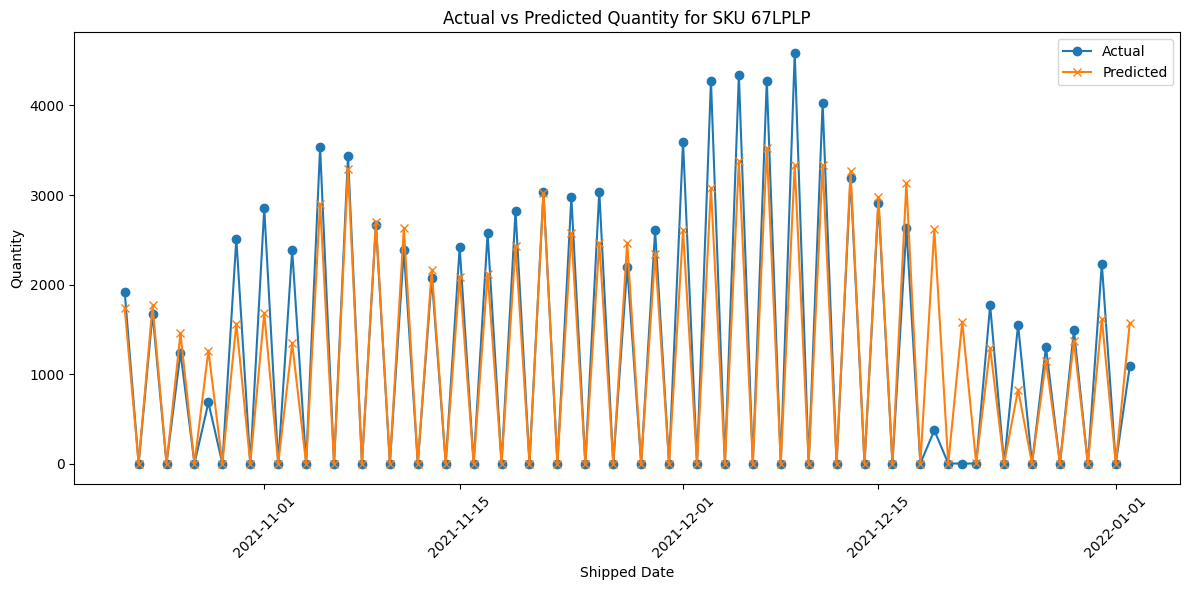

In [112]:
plot_df = test[test['sku'] == '4OCITK']
plt.figure(figsize=(12, 6))
plt.plot(plot_df['shipped_date'], plot_df['qty'], label='Actual', marker='o')
plt.plot(plot_df['shipped_date'], plot_df['qty_pred'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Quantity for SKU 67LPLP')
plt.xlabel('Shipped Date')
plt.ylabel('Quantity')
plt.legend()    
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### what if LightGBM: 

In [113]:
model_gbm = LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_gbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2370
[LightGBM] [Info] Number of data points in the train set: 2936, number of used features: 15
[LightGBM] [Info] Start training from score 3.378264
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

FileNotFoundError: [Errno 2] No such file or directory: '/Users/naaani/Documents/unigap/forecasting/forecast_env/lib/python3.13/site-packages/sklearn/utils/_repr_html/estimator.js'

FileNotFoundError: [Errno 2] No such file or directory: '/Users/naaani/Documents/unigap/forecasting/forecast_env/lib/python3.13/site-packages/sklearn/utils/_repr_html/estimator.js'

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
              n_estimators=500, random_state=42, subsample=0.8)

In [114]:
y_pred_gbm = model_gbm.predict(X_test_scaled)
y_pred_gbm_exp = np.expm1(y_pred_gbm)

r2_gbm = r2_score(np.expm1(y_test), y_pred_gbm_exp)
mae_gbm = mean_absolute_error(np.expm1(y_test), y_pred_gbm_exp)
rmse_gbm = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_gbm_exp))
print(f"LightGBM R²: {r2_gbm:.4f}")
print(f"LightGBM MAE: {mae_gbm:.4f}")
print(f"LightGBM RMSE: {rmse_gbm:.4f}")

LightGBM R²: -0.2736
LightGBM MAE: 1109.0404
LightGBM RMSE: 2386.4890


##### interpret RF features: 

In [115]:
importance = rf_model.feature_importances_

# Convert thành DataFrame cho dễ nhìn
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feat_imp)

               feature  importance
5                 lag1    0.826275
8       rolling_mean_7    0.095312
6                 lag7    0.025615
7                lag30    0.011089
13    mean_qty_sku_dow    0.010988
11      rolling_std_30    0.009960
10       rolling_std_7    0.009606
14  mean_qty_sku_month    0.003180
9      rolling_mean_30    0.002444
3           weekofyear    0.002126
1                  day    0.001053
12                 dow    0.000719
0                month    0.000693
2            dayofweek    0.000662
4          is_even_day    0.000277


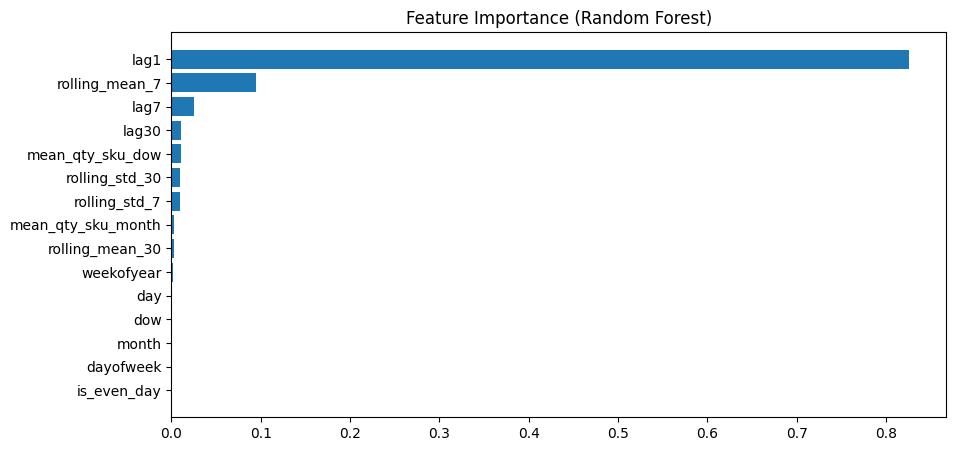

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

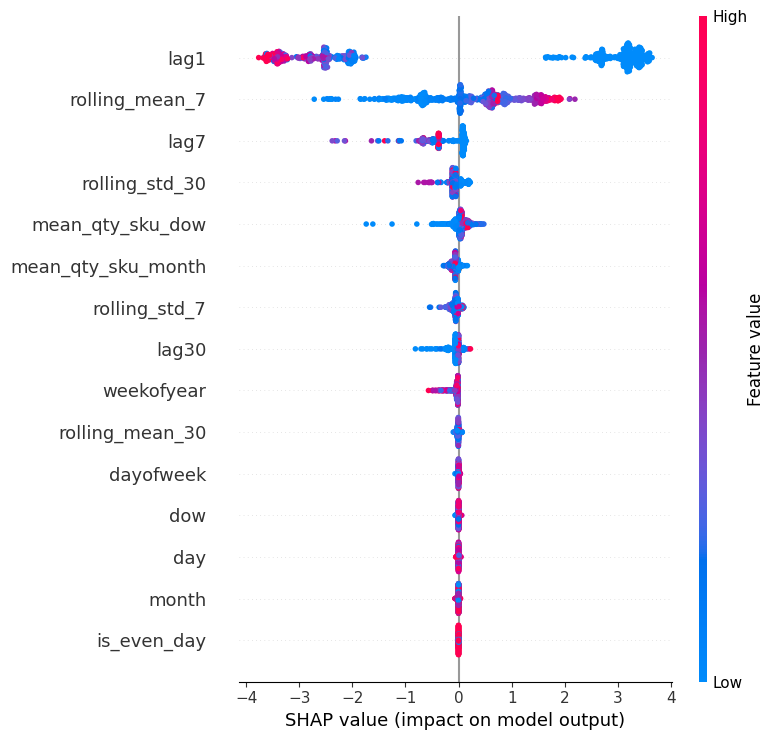

In [117]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test)

In [120]:

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

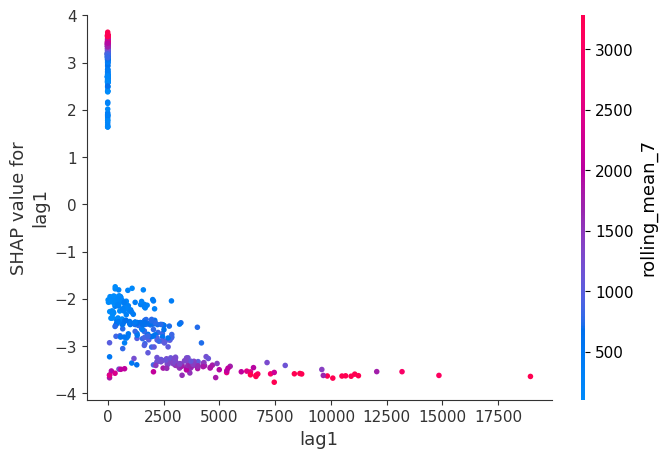

In [ ]:
shap.dependence_plot("lag1", shap_values, X_test)